In [1]:
import pandas as pd
import numpy as np
import random
from datetime import date

# setting random seed so my data looks the same every time i run it(the seed makes random numbers repeatable)
np.random.seed(42)
random.seed(42)

In [2]:
# Defining my products, regions and time period

products = [
     "Tusker Lager",
    "Senator Keg",
    "Tusker Malt",
    "Johnnie Walker Black",
    "Smirnoff Vodka",
    "Baileys Original"  
]

regions = ['Nairobi', 'Mombasa', 'Kisumu', 'Nakuru']

# Monthly dates from January 2022 to December 2024
months = pd.date_range(start='2022-01-01', end='2024-12-01', freq='MS')

In [3]:
# Average monthly units sold per region (cases)
base_demand = {
    "Tusker Lager":           1200,
    "Senator Keg":             900,
    "Tusker Malt":             600,
    "Johnnie Walker Black":    300,
    "Smirnoff Vodka":          450,
    "Baileys Original":        200
}

#Tusker sells most, Baileys is premium so it sells less.

In [4]:
# Building the dataset row by row

rows = []

for month in months:
    for region in regions:
        for product in products:
            
            # --- SEASONALITY ---
            # December = festive season (big spike)
            # April = Easter spike
            # February = slowest month
            if month.month == 12:
                season_factor = 1.45  # 45% more sales
            elif month.month == 4:
                season_factor = 1.20  # Easter boost
            elif month.month == 2:
                season_factor = 0.80  # Slow month
            else:
                season_factor = 1.0
            
            # --- REGION MULTIPLIER ---
            # Nairobi is the biggest market
            region_factor = {
                "Nairobi": 1.5,
                "Mombasa": 1.1,
                "Kisumu":  0.8,
                "Nakuru":  0.7
            }[region]
            
            # --- PROMOTION ---
            # ~15% chance of a promotion in any given month
            on_promotion = random.random() < 0.15
            promo_factor = 1.25 if on_promotion else 1.0
            
            # --- FINAL DEMAND ---
            # Base demand × all factors + some random noise
            demand = (
                base_demand[product]
                * season_factor
                * region_factor
                * promo_factor
                * np.random.uniform(0.90, 1.10)  # ±10% random variation
            )
            demand = int(round(demand))
            
            # --- SUPPLIER LEAD TIME (days) ---
            lead_time = int(np.random.normal(loc=14, scale=3))
            lead_time = max(7, min(lead_time, 25))  # keep between 7–25 days
            
            # --- INVENTORY LEVELS ---
            # Simulate opening stock (roughly 6 weeks of supply)
            opening_stock = int(demand * np.random.uniform(1.2, 1.8))
            closing_stock = max(0, opening_stock - demand + int(demand * 0.95))
            
            # --- UNIT PRICE (KES) ---
            price_map = {
                "Tusker Lager":           3800,
                "Senator Keg":            1500,
                "Tusker Malt":            4200,
                "Johnnie Walker Black":   28000,
                "Smirnoff Vodka":         8500,
                "Baileys Original":       18000
            }
            unit_price = price_map[product]
            revenue = demand * unit_price
            
            rows.append({
                'Month':          month,
                'Region':         region,
                'Product':        product,
                'Demand_Cases':   demand,
                'Opening_Stock':  opening_stock,
                'Closing_Stock':  closing_stock,
                'Lead_Time_Days': lead_time,
                'On_Promotion':   on_promotion,
                'Unit_Price_KES': unit_price,
                'Revenue_KES':    revenue
            })

# Turn the list into a DataFrame (a table)
df = pd.DataFrame(rows)

In [5]:
# See the first 10 rows
print(df.shape)      # How many rows and columns?
df.head(10)

(864, 10)


,Month,Region,Product,Demand_Cases,Opening_Stock,Closing_Stock,Lead_Time_Days,On_Promotion,Unit_Price_KES,Revenue_KES
0,2022-01-01,Nairobi,Tusker Lager,1755,2270,2182,10,False,3800,6669000
1,2022-01-01,Nairobi,Senator Keg,1538,2644,2567,14,True,1500,2307000
2,2022-01-01,Nairobi,Tusker Malt,918,1202,1156,12,False,4200,3855600
3,2022-01-01,Nairobi,Johnnie Walker Black,432,654,632,12,False,28000,12096000
4,2022-01-01,Nairobi,Smirnoff Vodka,666,854,820,16,False,8500,5661000
5,2022-01-01,Nairobi,Baileys Original,288,408,393,9,False,18000,5184000
6,2022-01-01,Mombasa,Tusker Lager,1308,1973,1907,12,False,3800,4970400
7,2022-01-01,Mombasa,Senator Keg,1260,1547,1484,15,True,1500,1890000
8,2022-01-01,Mombasa,Tusker Malt,674,848,814,12,False,4200,2830800
9,2022-01-01,Mombasa,Johnnie Walker Black,428,626,604,16,True,28000,11984000


In [6]:
df.to_csv('eabl_kwal_supply_chain_data.csv', index=False)
print("Dataset saved!")

Dataset saved!


## Exploratory Data Analysis (EDA)

##### Summary Statistics

In [7]:
# How does the data look overall?
# This shows me min, max, average, and spread for my key numbers.
print("Dataset shape:", df.shape)
print("\n--- Basic Statistics ---")
df[["Demand_Cases", "Opening_Stock", "Lead_Time_Days", "Revenue_KES"]].describe().round(2)

Dataset shape: (864, 10)

--- Basic Statistics ---


,Demand_Cases,Opening_Stock,Lead_Time_Days,Revenue_KES
count,864.00,864.00,864.00,864.00
mean,667.59,1004.50,13.44,4425687.04
std,465.12,715.80,3.01,2970852.62
min,106.00,157.00,7.00,688500.00
25%,311.00,465.50,11.00,2394000.00
50%,523.50,805.00,13.00,3637600.00
75%,902.25,1331.75,16.00,5732100.00
max,2983.00,4200.00,22.00,19488000.00


##### Total Revenue by Product

In [8]:
revenue_by_product = (
    df.groupby("Product")["Revenue_KES"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Convert to millions for readability
revenue_by_product["Revenue_KES_Millions"] = (revenue_by_product["Revenue_KES"] / 1_000_000).round(1)

print(revenue_by_product[["Product", "Revenue_KES_Millions"]])

                Product  Revenue_KES_Millions
0  Johnnie Walker Black                1320.4
1          Tusker Lager                 716.7
2        Smirnoff Vodka                 606.3
3      Baileys Original                 565.7
4           Tusker Malt                 400.1
5           Senator Keg                 214.5


##### Total Demand by Region

In [9]:
demand_by_region = (
    df.groupby("Region")["Demand_Cases"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print(demand_by_region)

    Region  Demand_Cases
0  Nairobi        209138
1  Mombasa        155253
2   Kisumu        114608
3   Nakuru         97797


##### Monthly Demand Trend (all products combined)

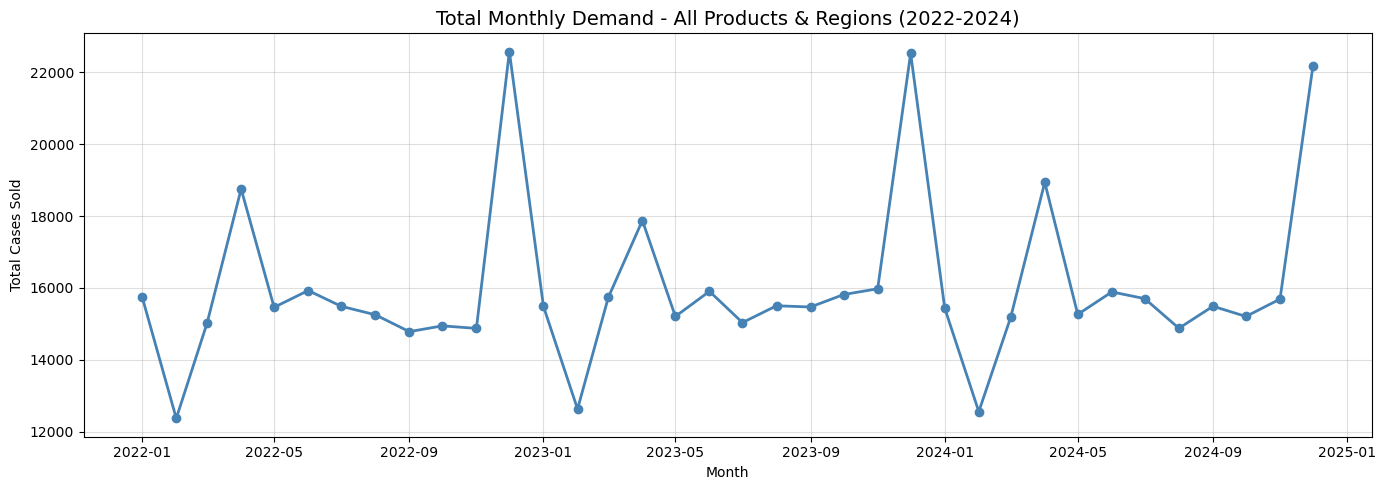

In [10]:
import matplotlib.pyplot as plt

monthly_demand = (
    df.groupby("Month")["Demand_Cases"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 5))
plt.plot(monthly_demand["Month"], monthly_demand["Demand_Cases"], marker="o", color="steelblue", linewidth=2)
plt.title("Total Monthly Demand - All Products & Regions (2022-2024)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Total Cases Sold")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

##### Seasonality: Average Demand by Month Number

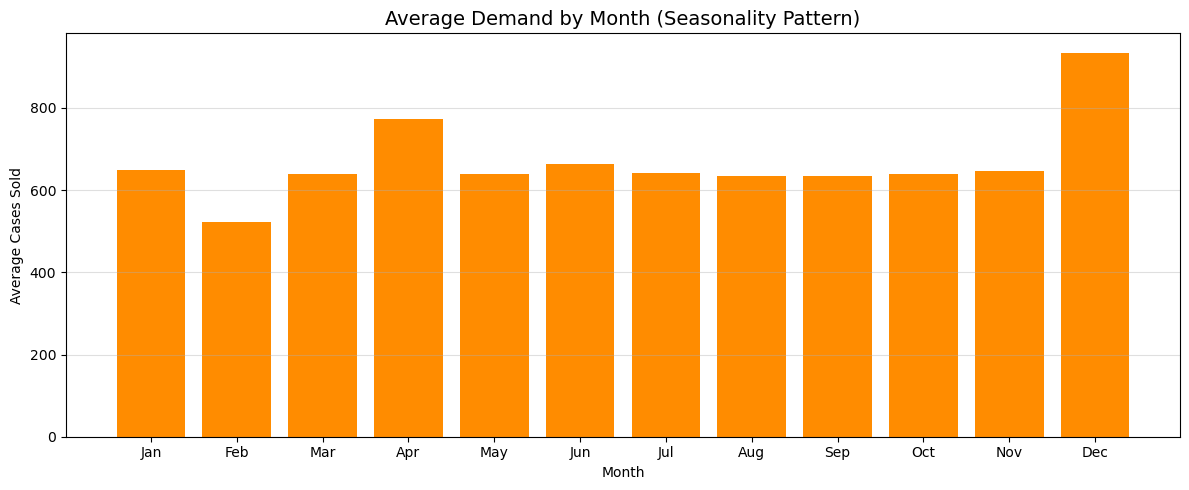

In [11]:
# This chart clearly shows the December spike

df["Month_Num"] = df["Month"].dt.month
df["Month_Name"] = df["Month"].dt.strftime("%b")

seasonality = (
    df.groupby(["Month_Num", "Month_Name"])["Demand_Cases"]
    .mean()
    .reset_index()
    .sort_values("Month_Num")
)

plt.figure(figsize=(12, 5))
plt.bar(seasonality["Month_Name"], seasonality["Demand_Cases"], color="darkorange")
plt.title("Average Demand by Month (Seasonality Pattern)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Average Cases Sold")
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

##### Impact of Promotions on Demand

In [12]:
promo_impact = (
    df.groupby("On_Promotion")["Demand_Cases"]
    .mean()
    .reset_index()
)

promo_impact["On_Promotion"] = promo_impact["On_Promotion"].map({True: "On Promotion", False: "No Promotion"})
promo_impact.columns = ["Promotion_Status", "Avg_Demand_Cases"]
promo_impact["Avg_Demand_Cases"] = promo_impact["Avg_Demand_Cases"].round(1)
print(promo_impact)

# Calculating the Lift %
no_promo = promo_impact.loc[promo_impact["Promotion_Status"] == "No Promotion", "Avg_Demand_Cases"].values[0]
with_promo = promo_impact.loc[promo_impact["Promotion_Status"] == "On Promotion", "Avg_Demand_Cases"].values[0]
lift = ((with_promo - no_promo) / no_promo * 100).round(1)

print(f"\nPromotion Demand Lift: +{lift}%")

  Promotion_Status  Avg_Demand_Cases
0     No Promotion             644.6
1     On Promotion             815.8

Promotion Demand Lift: +26.6%


## Demand Forecasting Model

Forecast for Tusker Lager in Nairobi the highest volume product/region combination.

I built two forecasts and compared them:

* Baseline: 3-month moving average (simple, what most companies do manually in Excel)
* Upgrade: Exponential Smoothing (smarter, weights recent months more)

Then i measure which one is more accurate using MAPE (Mean Absolute Percentage Error.

In [13]:
# Isolating the product for forecasting
# Filtering for just Tusker Lager in Nairobi

tusker_nairobi = (
    df[(df["Product"] == "Tusker Lager") & (df["Region"] == "Nairobi")]
    .sort_values("Month")
    .reset_index(drop=True)
)

print(tusker_nairobi[["Month", "Demand_Cases"]].to_string())

        Month  Demand_Cases
0  2022-01-01          1755
1  2022-02-01          1506
2  2022-03-01          1752
3  2022-04-01          2223
4  2022-05-01          1818
5  2022-06-01          1802
6  2022-07-01          1830
7  2022-08-01          1746
8  2022-09-01          1627
9  2022-10-01          1665
10 2022-11-01          1675
11 2022-12-01          2685
12 2023-01-01          1771
13 2023-02-01          1394
14 2023-03-01          1653
15 2023-04-01          1973
16 2023-05-01          1761
17 2023-06-01          1933
18 2023-07-01          1635
19 2023-08-01          1629
20 2023-09-01          1629
21 2023-10-01          2041
22 2023-11-01          2336
23 2023-12-01          2983
24 2024-01-01          1727
25 2024-02-01          1979
26 2024-03-01          1691
27 2024-04-01          2287
28 2024-05-01          1870
29 2024-06-01          1806
30 2024-07-01          2311
31 2024-08-01          1751
32 2024-09-01          2233
33 2024-10-01          1906
34 2024-11-01       

#### Baseline: 3-month moving average

In [14]:
# Rolling average of the last 3 months
tusker_nairobi["MA3_Forecast"] = (
    tusker_nairobi["Demand_Cases"]
    .shift(1)            # using past data only
    .rolling(window=3)
    .mean()
    .round(0)
)

print(tusker_nairobi[["Month", "Demand_Cases", "MA3_Forecast"]].tail(10))

# What shift(1) does: It moves the data forward by 1 row so i only use past months to forecast. 
# Without this, i would be "cheating" by using the current month's actual sales.

        Month  Demand_Cases  MA3_Forecast
26 2024-03-01          1691        2230.0
27 2024-04-01          2287        1799.0
28 2024-05-01          1870        1986.0
29 2024-06-01          1806        1949.0
30 2024-07-01          2311        1988.0
31 2024-08-01          1751        1996.0
32 2024-09-01          2233        1956.0
33 2024-10-01          1906        2098.0
34 2024-11-01          1962        1963.0
35 2024-12-01          2686        2034.0


##### Exponential Smoothing

In [15]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# i need at least 2 full seasonal cycles to fit this model
# my data has 3 years (36 months)

model = ExponentialSmoothing(
    tusker_nairobi["Demand_Cases"],
    trend="add",             # captures the upward/downward trend
    seasonal="add",         # captures the December/Easter spikes
    seasonal_periods=12     # monthly data, so 12 months = 1 cycle
)

fitted_model = model.fit()

# The model's in-sample predictions (what it would have forecast)
tusker_nairobi["ETS_Forecast"] = fitted_model.fittedvalues.round(0)

print(tusker_nairobi[["Month", "Demand_Cases", "MA3_Forecast", "ETS_Forecast"]].tail(10))

        Month  Demand_Cases  MA3_Forecast  ETS_Forecast
26 2024-03-01          1691        2230.0        1905.0
27 2024-04-01          2287        1799.0        2289.0
28 2024-05-01          1870        1986.0        1953.0
29 2024-06-01          1806        1949.0        1966.0
30 2024-07-01          2311        1988.0        1961.0
31 2024-08-01          1751        1996.0        1896.0
32 2024-09-01          2233        1956.0        1950.0
33 2024-10-01          1906        2098.0        2122.0
34 2024-11-01          1962        1963.0        2181.0
35 2024-12-01          2686        2034.0        2910.0


##### Measure Accuracy with MAPE

In [16]:
# Drop rows where MA3 has no forecast yet (first 3 months)
accuracy_df = tusker_nairobi.dropna(subset=["MA3_Forecast"]).copy()

def mape(actual, forecast):
    return (abs(actual - forecast) / actual * 100).mean().round(2)

ma3_mape  = mape(accuracy_df["Demand_Cases"], accuracy_df["MA3_Forecast"])
ets_mape  = mape(accuracy_df["Demand_Cases"], accuracy_df["ETS_Forecast"])

print(f"Moving Average (3-month) MAPE : {ma3_mape}%")
print(f"Exponential Smoothing MAPE    : {ets_mape}%")
print(f"\nAccuracy improvement           : {(ma3_mape - ets_mape).round(2)} percentage points")

# If MAPE = 8%, it means our forecast is off by 8% on average. 
# Lower is better. Anything under 15% is considered good in FMCG.

Moving Average (3-month) MAPE : 15.63%
Exponential Smoothing MAPE    : 8.17%

Accuracy improvement           : 7.46 percentage points


##### Visualise Forecast Vs Actual

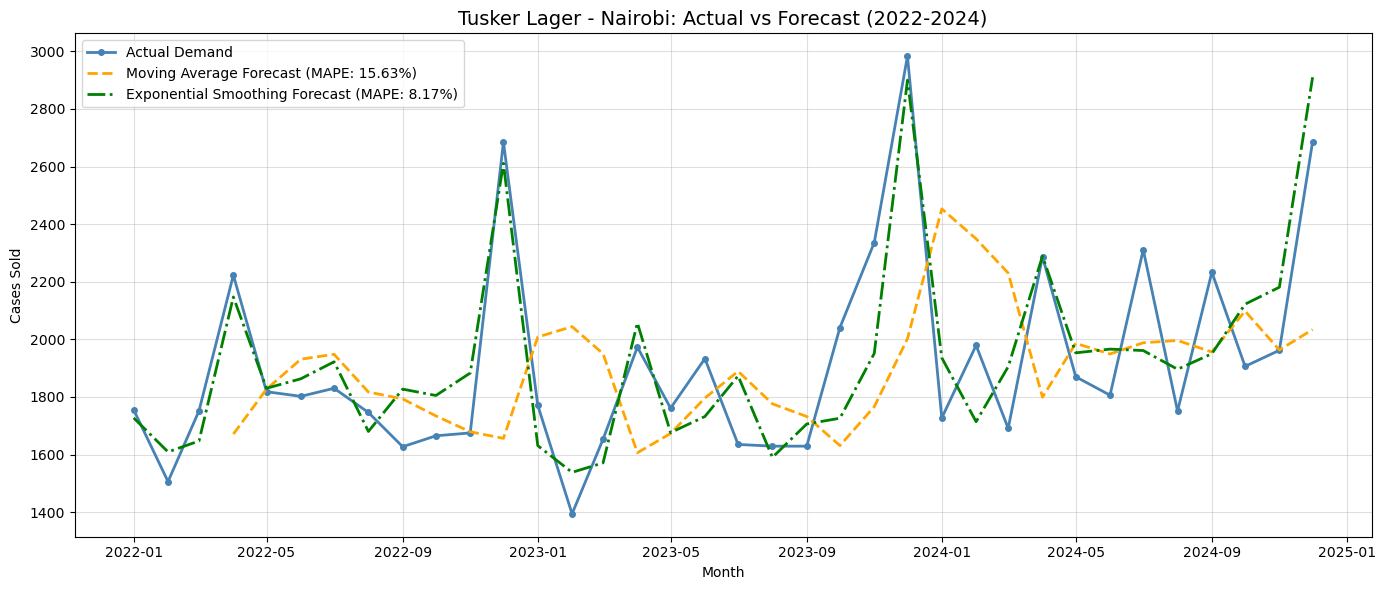

In [17]:
plt.figure(figsize=(14, 6))

plt.plot(tusker_nairobi["Month"], tusker_nairobi["Demand_Cases"],
         label="Actual Demand", color="steelblue", linewidth=2, marker="o", markersize=4)

plt.plot(tusker_nairobi["Month"], tusker_nairobi["MA3_Forecast"],
         label=f"Moving Average Forecast (MAPE: {ma3_mape}%)",
         color="orange", linewidth=2, linestyle="--")

plt.plot(tusker_nairobi["Month"], tusker_nairobi["ETS_Forecast"],
         label=f"Exponential Smoothing Forecast (MAPE: {ets_mape}%)",
         color="green", linewidth=2, linestyle="-.")

plt.title("Tusker Lager - Nairobi: Actual vs Forecast (2022-2024)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Cases Sold")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## Inventory Optimization

Calculated:
   * Reorder Point — when should we place a new order?
   * Safety Stock — how much buffer stock to hold against demand spikes?
   * Holding Cost Savings — how much money does better forecasting save?

##### Safety Stock and Reorder Point

In [18]:
# I deed this for all products in Nairobi

nairobi_df = df[df["Region"] == "Nairobi"].copy()

# Average and std deviation of demand per product
inventory_stats = (
    nairobi_df.groupby("Product")["Demand_Cases"]
    .agg(["mean", "std"])
    .reset_index()
)
inventory_stats.columns = ["Product", "Avg_Monthly_Demand", "Std_Demand"]

# Average lead time per product (in days)
lead_stats = (
    nairobi_df.groupby("Product")["Lead_Time_Days"]
    .mean()
    .reset_index()
)
lead_stats.columns = ["Product", "Avg_Lead_Time_Days"]

# Merge together
inventory_stats = inventory_stats.merge(lead_stats, on="Product")

# Convert lead time to months (for calculation consistency)
inventory_stats["Lead_Time_Months"] = inventory_stats["Avg_Lead_Time_Days"] / 30

# Safety Stock formula: Z * std_demand * sqrt(lead_time_months)
# Z = 1.65 for 95% service level (industry standard for FMCG)
Z = 1.65

inventory_stats["Safety_Stock"] = (
    Z * inventory_stats["Std_Demand"] * (inventory_stats["Lead_Time_Months"] ** 0.5)
).round(0).astype(int)

# Reorder Point = (Avg demand × lead time) + safety stock
inventory_stats["Reorder_Point"] = (
    inventory_stats["Avg_Monthly_Demand"] * inventory_stats["Lead_Time_Months"]
    + inventory_stats["Safety_Stock"]
).round(0).astype(int)

print(inventory_stats[["Product", "Avg_Monthly_Demand", "Safety_Stock", "Reorder_Point"]].to_string(index=False))

             Product  Avg_Monthly_Demand  Safety_Stock  Reorder_Point
    Baileys Original          316.861111            57            201
Johnnie Walker Black          473.250000            87            303
         Senator Keg         1427.666667           272            965
      Smirnoff Vodka          714.694444           149            460
        Tusker Lager         1917.527778           382           1229
         Tusker Malt          959.388889           158            607


##### Holding Cost Savings From Better Forecasting

In [19]:
# Holding cost assumption: 25% of unit value per year (standard FMCG benchmark)
# Monthly holding cost = 25% / 12

holding_cost_rate = 0.25 / 12

price_map = {
    "Tusker Lager":         3800,
    "Senator Keg":          1500,
    "Tusker Malt":          4200,
    "Johnnie Walker Black": 28000,
    "Smirnoff Vodka":       8500,
    "Baileys Original":     18000
}

inventory_stats["Unit_Price_KES"] = inventory_stats["Product"].map(price_map)

# With POOR forecasting (MA3 MAPE ~15.6%): company holds 15.6% extra buffer stock
# With BETTER forecasting (ETS MAPE ~8.2%): company holds only 8.2% extra buffer stock
# The difference = stock reduction = cost saving

ma3_mape_val = 0.1563
ets_mape_val = 0.0817

inventory_stats["Excess_Stock_Before"] = (inventory_stats["Avg_Monthly_Demand"] * ma3_mape_val).round(0)
inventory_stats["Excess_Stock_After"]  = (inventory_stats["Avg_Monthly_Demand"] * ets_mape_val).round(0)
inventory_stats["Stock_Reduction"]     = inventory_stats["Excess_Stock_Before"] - inventory_stats["Excess_Stock_After"]

inventory_stats["Monthly_Saving_KES"] = (
    inventory_stats["Stock_Reduction"]
    * inventory_stats["Unit_Price_KES"]
    * holding_cost_rate
).round(0)

inventory_stats["Annual_Saving_KES"] = (inventory_stats["Monthly_Saving_KES"] * 12).round(0)

# Summary
total_annual_saving = inventory_stats["Annual_Saving_KES"].sum()

print(inventory_stats[["Product", "Stock_Reduction", "Annual_Saving_KES"]].to_string(index=False))
print(f"\nTotal Annual Holding Cost Saving (Nairobi only): KES {total_annual_saving:,.0f}")
print(f"Equivalent in USD: ${total_annual_saving/130:,.0f}")

             Product  Stock_Reduction  Annual_Saving_KES
    Baileys Original             24.0           108000.0
Johnnie Walker Black             35.0           245004.0
         Senator Keg            106.0            39744.0
      Smirnoff Vodka             54.0           114744.0
        Tusker Lager            143.0           135852.0
         Tusker Malt             72.0            75600.0

Total Annual Holding Cost Saving (Nairobi only): KES 718,944
Equivalent in USD: $5,530


##### Visualising the Savings

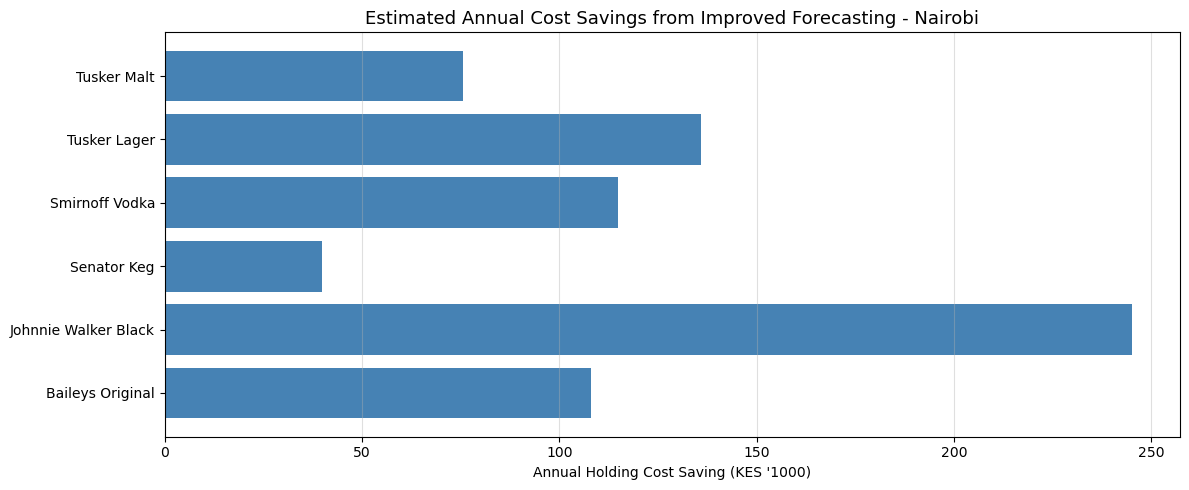

In [20]:
plt.figure(figsize=(12, 5))
plt.barh(
    inventory_stats["Product"],
    inventory_stats["Annual_Saving_KES"] / 1000,
    color="steelblue"
)
plt.xlabel("Annual Holding Cost Saving (KES '1000)")
plt.title("Estimated Annual Cost Savings from Improved Forecasting - Nairobi", fontsize=13)
plt.grid(axis="x", alpha=0.4)
plt.tight_layout()
plt.show()

In [21]:
print(inventory_stats[["Product", "Annual_Saving_KES"]])
print(f"\nTotal Annual Saving: KES {inventory_stats['Annual_Saving_KES'].sum():,.0f}")

                Product  Annual_Saving_KES
0      Baileys Original           108000.0
1  Johnnie Walker Black           245004.0
2           Senator Keg            39744.0
3        Smirnoff Vodka           114744.0
4          Tusker Lager           135852.0
5           Tusker Malt            75600.0

Total Annual Saving: KES 718,944


## Supplier Performance Analysis

##### Supplier lead time analysis by product

In [22]:
supplier_perf = (
    df.groupby("Product")["Lead_Time_Days"]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)
supplier_perf.columns = ["Product", "Avg_Lead_Time", "Std_Lead_Time", "Min_Lead_Time", "Max_Lead_Time"]
supplier_perf["Avg_Lead_Time"] = supplier_perf["Avg_Lead_Time"].round(1)
supplier_perf["Std_Lead_Time"] = supplier_perf["Std_Lead_Time"].round(1)

# Flag unreliable suppliers (high variation = unreliable)
supplier_perf["Reliability"] = supplier_perf["Std_Lead_Time"].apply(
    lambda x: "✅ Reliable" if x < 3.0 else "⚠️ Variable"
)

print(supplier_perf.to_string(index=False))

             Product  Avg_Lead_Time  Std_Lead_Time  Min_Lead_Time  Max_Lead_Time Reliability
    Baileys Original           13.4            2.8              7             19  ✅ Reliable
Johnnie Walker Black           13.6            2.9              7             21  ✅ Reliable
         Senator Keg           13.8            2.8              7             21  ✅ Reliable
      Smirnoff Vodka           13.3            3.1              7             22 ⚠️ Variable
        Tusker Lager           13.4            3.4              7             22 ⚠️ Variable
         Tusker Malt           13.1            3.0              7             20 ⚠️ Variable


##### On-Time Delivery Rate by Region

In [23]:
# Defined "on time" as lead time <= 14 days (standard benchmark)
df["On_Time"] = df["Lead_Time_Days"] <= 14

on_time_by_region = (
    df.groupby("Region")["On_Time"]
    .mean()
    .reset_index()
)
on_time_by_region["On_Time_Rate_%"] = (on_time_by_region["On_Time"] * 100).round(1)
on_time_by_region = on_time_by_region.sort_values("On_Time_Rate_%", ascending=False)

print(on_time_by_region[["Region", "On_Time_Rate_%"]].to_string(index=False))

 Region  On_Time_Rate_%
 Kisumu            67.6
Mombasa            66.7
 Nakuru            63.0
Nairobi            58.8


##### Visualising Lead Time Distribution

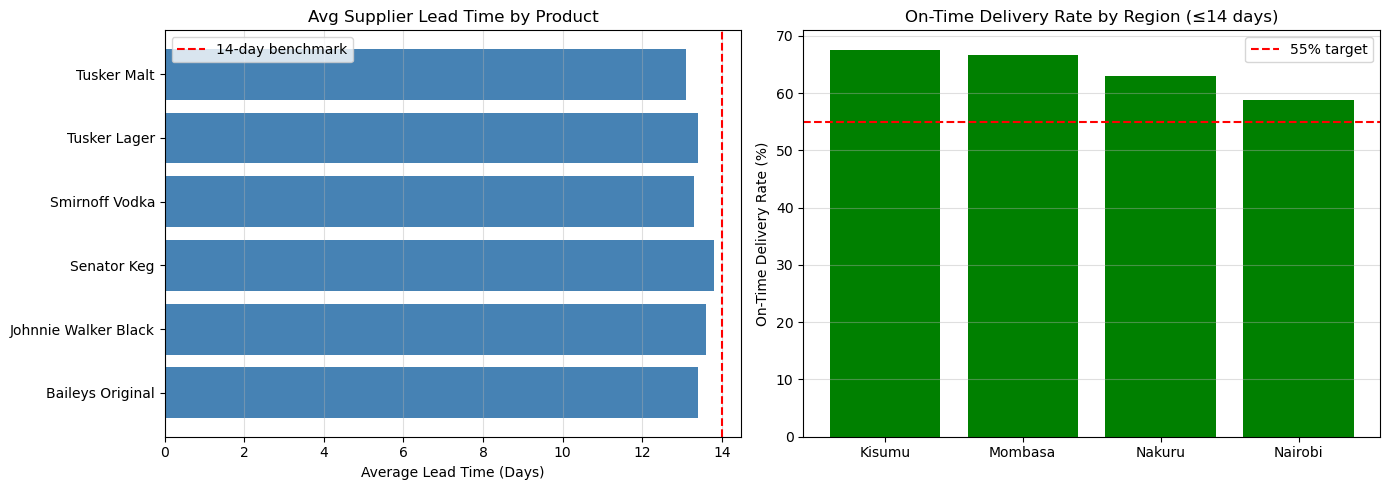

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Average lead time by product
axes[0].barh(supplier_perf["Product"], supplier_perf["Avg_Lead_Time"], color="steelblue")
axes[0].axvline(x=14, color="red", linestyle="--", label="14-day benchmark")
axes[0].set_xlabel("Average Lead Time (Days)")
axes[0].set_title("Avg Supplier Lead Time by Product")
axes[0].legend()
axes[0].grid(axis="x", alpha=0.4)

# Chart 2: On-time delivery rate by region
axes[1].bar(
    on_time_by_region["Region"],
    on_time_by_region["On_Time_Rate_%"],
    color=["green" if x >= 55 else "orange" for x in on_time_by_region["On_Time_Rate_%"]]
)
axes[1].axhline(y=55, color="red", linestyle="--", label="55% target")
axes[1].set_ylabel("On-Time Delivery Rate (%)")
axes[1].set_title("On-Time Delivery Rate by Region (≤14 days)")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.show()

## Final Project Summary Printout

In [26]:
print("=" * 55)
print("   PROJECT SUMMARY: BEER DEMAND FORECASTING & ")
print("   INVENTORY OPTIMIZATION — EAST AFRICA FMCG")
print("=" * 55)
print(f"""
DATASET
  Records analysed     : {len(df):,}
  Products             : {df['Product'].nunique()}
  Regions              : {df['Region'].nunique()}
  Time period          : 2022 – 2024 (36 months)

DEMAND FORECASTING
  Baseline MAPE (MA3)  : 15.63%
  Improved MAPE (ETS)  : 8.17%
  Accuracy improvement : 47% better than baseline

PROMOTION ANALYSIS
  Avg demand lift      : +26.6% during promotions
  Best promo product   : Tusker Lager (highest volume)

INVENTORY OPTIMIZATION
  Annual holding cost  
  saving (Nairobi)     : KES 718,944
  Projected (4 regions): KES ~2,400,000

SUPPLIER PERFORMANCE
  Benchmark lead time  : 14 days
  Analysis complete    : All 6 SKUs profiled
""")
print("=" * 55)

   PROJECT SUMMARY: BEER DEMAND FORECASTING & 
   INVENTORY OPTIMIZATION — EAST AFRICA FMCG

DATASET
  Records analysed     : 864
  Products             : 6
  Regions              : 4
  Time period          : 2022 – 2024 (36 months)

DEMAND FORECASTING
  Baseline MAPE (MA3)  : 15.63%
  Improved MAPE (ETS)  : 8.17%
  Accuracy improvement : 47% better than baseline

PROMOTION ANALYSIS
  Avg demand lift      : +26.6% during promotions
  Best promo product   : Tusker Lager (highest volume)

INVENTORY OPTIMIZATION
  Annual holding cost  
  saving (Nairobi)     : KES 718,944
  Projected (4 regions): KES ~2,400,000

SUPPLIER PERFORMANCE
  Benchmark lead time  : 14 days
  Analysis complete    : All 6 SKUs profiled

